### 통계 검정 및 상관관계 분석

In [3]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import (
    shapiro, mannwhitneyu, kruskal,
    wilcoxon, ks_2samp, pointbiserialr,
    spearmanr, probplot
)
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
 
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
base_path = 'data/new_data'
df_A     = pd.read_csv(os.path.join(base_path, 'df_A_main.csv'))
df_imp_A = pd.read_csv(os.path.join(base_path, 'df_imp_A_main.csv'))

# start_time datetime 변환 추가
df_A['start_time'] = pd.to_datetime(df_A['start_time'], errors='coerce')
df_imp_A['start_time'] = pd.to_datetime(df_imp_A['start_time'], errors='coerce')

df_A_valid = df_A[df_A['cap_flag'] == 'valid'].copy()
df_A_valid = df_A_valid.dropna(subset=['start_time'])   # 추가
df_imp_A = df_imp_A.dropna(subset=['start_time'])       # 추가

df_A_valid = df_A_valid.sort_values(['battery_id','discharge_cycle_raw'])
df_A_valid['SOH_diff'] = df_A_valid.groupby('battery_id')['SOH_relative'].diff()

# impedance merge_asof
df_imp_A['Re']  = pd.to_numeric(df_imp_A['Re'],  errors='coerce')
df_imp_A['Rct'] = pd.to_numeric(df_imp_A['Rct'], errors='coerce')
df_imp_A = df_imp_A.sort_values(['battery_id','start_time']).reset_index(drop=True)
df_imp_A['Re_cumean']  = df_imp_A.groupby('battery_id')['Re'].expanding().mean().reset_index(level=0, drop=True)
df_imp_A['Rct_cumean'] = df_imp_A.groupby('battery_id')['Rct'].expanding().mean().reset_index(level=0, drop=True)

results_list = []
for bid in df_A_valid['battery_id'].unique():
    d = df_A_valid[df_A_valid['battery_id']==bid].sort_values('start_time').reset_index(drop=True)
    i = df_imp_A[df_imp_A['battery_id']==bid][['start_time','Re_cumean','Rct_cumean']].sort_values('start_time').reset_index(drop=True)
    merged = pd.merge_asof(d, i, on='start_time', direction='backward')
    results_list.append(merged)

df_A_valid = pd.concat(results_list, ignore_index=True)
df_A_valid = df_A_valid.rename(columns={'Re_cumean':'Re_mean','Rct_cumean':'Rct_mean'})
df_A_valid = df_A_valid.sort_values(['battery_id','discharge_cycle_raw'])
df_A_valid['Re_mean']  = df_A_valid.groupby('battery_id')['Re_mean'].ffill()
df_A_valid['Rct_mean'] = df_A_valid.groupby('battery_id')['Rct_mean'].ffill()

BATTERY_COLORS = {'B0005':'#378ADD','B0006':'#1D9E75','B0007':'#D85A30','B0018':'#8B5CF6'}
batteries = ['B0005','B0006','B0007','B0018']

def rank_biserial(x, y):
    u, _ = mannwhitneyu(x, y, alternative='two-sided')
    return 1 - (2 * u) / (len(x) * len(y))

def bonferroni_p(p_values):
    n = len(p_values)
    return [min(p * n, 1.0) for p in p_values]

def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

print("=" * 60)
print("데이터 로드 완료!")
print(f"df_A_valid: {len(df_A_valid)}행")
print(f"배터리: {sorted(df_A_valid['battery_id'].unique())}")
print("=" * 60)

데이터 로드 완료!
df_A_valid: 636행
배터리: ['B0005', 'B0006', 'B0007', 'B0018']



검정 1. Kruskal-Wallis + pairwise Mann-Whitney + RBC
배터리 4개 SOH 감소 속도 비교

[기술통계]
B0005: 평균=0.4438%/사이클, 중앙값=0.2900, n=167
B0006: 평균=0.7128%/사이클, 중앙값=0.5200, n=167
B0007: 평균=0.3695%/사이클, 중앙값=0.2700, n=167
B0018: 평균=0.7692%/사이클, 중앙값=0.5400, n=131

[Step 1] Kruskal-Wallis: H=59.7966, p=0.0000
해석: 집단 간 유의미한 차이 있음

[Step 2] pairwise Mann-Whitney (Bonferroni 보정)
쌍                           U     p(raw)      p(보정)      RBC     유의
-----------------------------------------------------------------
B0005 vs B0006       11309.0     0.0028     0.0169    0.189    sig
B0005 vs B0007       16160.0     0.0120     0.0721   -0.159       
B0005 vs B0018        7005.0     0.0000     0.0000    0.360    sig
B0006 vs B0007       18545.0     0.0000     0.0000   -0.330    sig
B0006 vs B0018       10128.0     0.2725     1.0000    0.074       
B0007 vs B0018        5696.0     0.0000     0.0000    0.479    sig

[RBC 효과크기 해석]
|RBC| < 0.1: 무시 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대


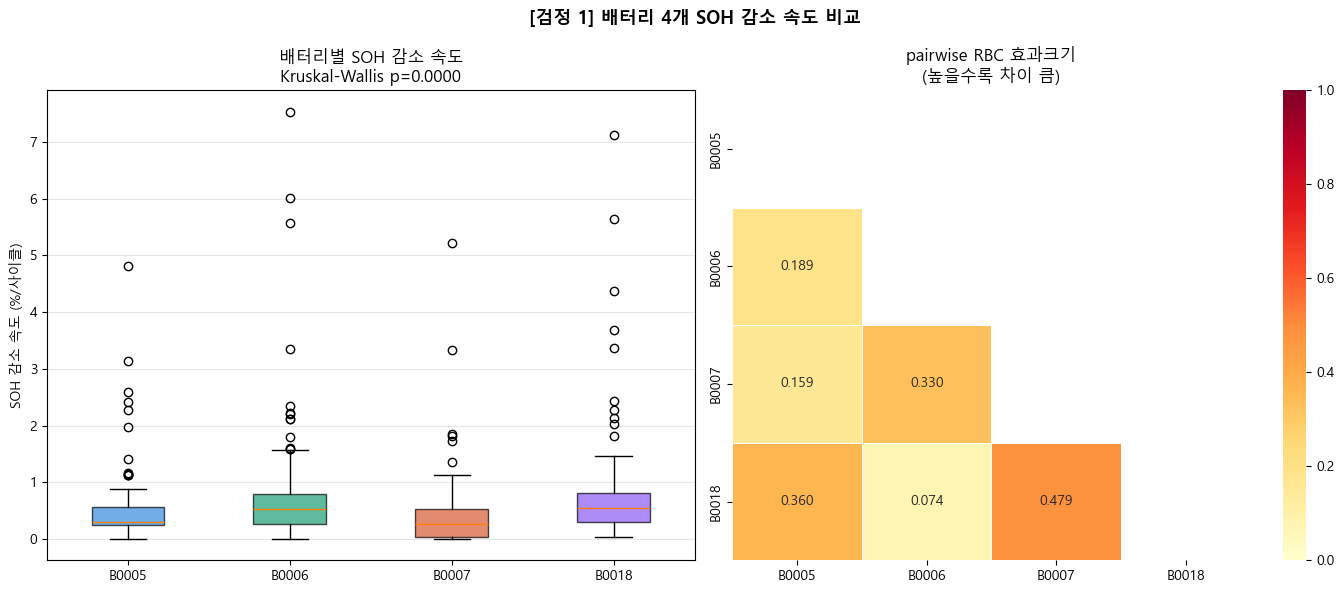

[저장] stat_kruskal_soh_speed.png


In [6]:
print("\n" + "=" * 60)
print("검정 1. Kruskal-Wallis + pairwise Mann-Whitney + RBC")
print("배터리 4개 SOH 감소 속도 비교")
print("=" * 60)
 
groups = {
    bid: df_A_valid[df_A_valid['battery_id']==bid]['SOH_diff'].dropna().abs().values
    for bid in batteries
}
 
print("\n[기술통계]")
for bid, vals in groups.items():
    print(f"{bid}: 평균={vals.mean():.4f}%/사이클, 중앙값={np.median(vals):.4f}, n={len(vals)}")
 
stat, p = kruskal(*groups.values())
print(f"\n[Step 1] Kruskal-Wallis: H={stat:.4f}, p={p:.4f}")
print(f"해석: {'집단 간 유의미한 차이 있음' if p < 0.05 else '차이 없음'}")
 
pairs = list(combinations(batteries, 2))
raw_ps = []
pair_stats = []
for b1, b2 in pairs:
    u, p_raw = mannwhitneyu(groups[b1], groups[b2], alternative='two-sided')
    rbc = rank_biserial(groups[b1], groups[b2])
    raw_ps.append(p_raw)
    pair_stats.append((b1, b2, u, p_raw, rbc))
 
bonf_ps = bonferroni_p(raw_ps)
print(f"\n[Step 2] pairwise Mann-Whitney (Bonferroni 보정)")
print(f"{'쌍':<20} {'U':>8} {'p(raw)':>10} {'p(보정)':>10} {'RBC':>8} {'유의':>6}")
print("-" * 65)
for i, (b1, b2, u, p_raw, rbc) in enumerate(pair_stats):
    p_adj = bonf_ps[i]
    sig = 'sig' if p_adj < 0.05 else ''
    print(f"{b1} vs {b2:<10} {u:>8.1f} {p_raw:>10.4f} {p_adj:>10.4f} {rbc:>8.3f} {sig:>6}")
 
print("\n[RBC 효과크기 해석]")
print("|RBC| < 0.1: 무시 / 0.1~0.3: 소 / 0.3~0.5: 중 / >0.5: 대")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
data_list = [groups[b] for b in batteries]
bp = axes[0].boxplot(data_list, labels=batteries, patch_artist=True)
for patch, bid in zip(bp['boxes'], batteries):
    patch.set_facecolor(BATTERY_COLORS[bid])
    patch.set_alpha(0.7)
axes[0].set_ylabel('SOH 감소 속도 (%/사이클)')
axes[0].set_title(f'배터리별 SOH 감소 속도\nKruskal-Wallis p={p:.4f}')
axes[0].grid(axis='y', alpha=0.3)
 
rbc_matrix = pd.DataFrame(np.zeros((4,4)), index=batteries, columns=batteries)
for b1, b2, u, p_raw, rbc in pair_stats:
    rbc_matrix.loc[b1,b2] = abs(rbc)
    rbc_matrix.loc[b2,b1] = abs(rbc)
mask = np.triu(np.ones_like(rbc_matrix, dtype=bool))
sns.heatmap(rbc_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1], mask=mask, vmin=0, vmax=1, linewidths=0.5)
axes[1].set_title('pairwise RBC 효과크기\n(높을수록 차이 큼)')
plt.suptitle('[검정 1] 배터리 4개 SOH 감소 속도 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_kruskal_soh_speed.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_kruskal_soh_speed.png')


검정 2. Jonckheere-Terpstra (단조 증가 검정)
열화 단계별 Re 단조증가 검증

[구간별 Re 기술통계]
r_90이상: 평균=0.0507Ohm, 중앙값=0.0466, n=154
v_80-90: 평균=0.0529Ohm, 중앙값=0.0490, n=156
e_70-80: 평균=0.0578Ohm, 중앙값=0.0542, n=208
c_70미만: 평균=0.0687Ohm, 중앙값=0.0688, n=61

[인접 구간 pairwise Mann-Whitney (단조성 확인)]
r_90이상 < v_80-90: p=0.0000, RBC=0.309 [sig]
v_80-90 < e_70-80: p=0.0000, RBC=0.572 [sig]
e_70-80 < c_70미만: p=0.0000, RBC=1.000 [sig]

Kruskal-Wallis (전체): H=267.6573, p=0.0000
단조 증가 패턴: 확인됨


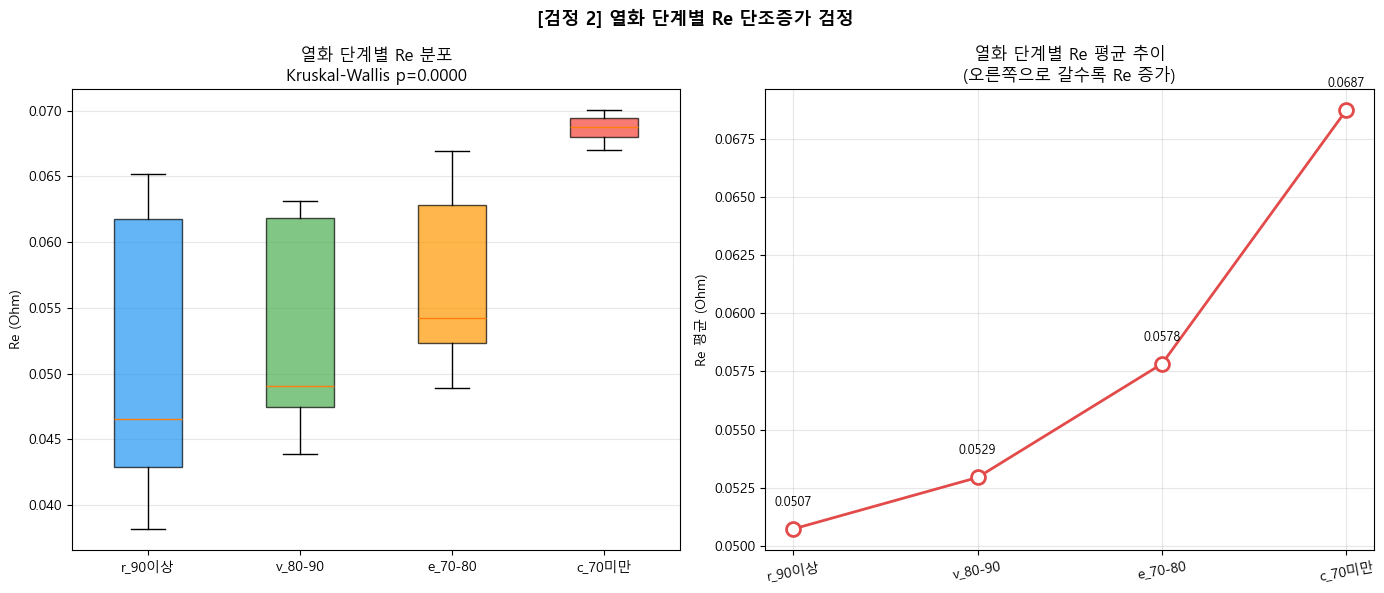

[저장] stat_jonckheere_re_stage.png


In [7]:
print("\n" + "=" * 60)
print("검정 2. Jonckheere-Terpstra (단조 증가 검정)")
print("열화 단계별 Re 단조증가 검증")
print("=" * 60)
 
df_A_valid['soh_stage'] = pd.cut(
    df_A_valid['SOH_relative'],
    bins=[0, 70, 80, 90, 110],
    labels=['c_70미만', 'e_70-80', 'v_80-90', 'r_90이상']
)
 
stage_order = ['r_90이상', 'v_80-90', 'e_70-80', 'c_70미만']
stage_data = {
    s: df_A_valid[df_A_valid['soh_stage']==s]['Re_mean'].dropna().values
    for s in stage_order
}
 
print("\n[구간별 Re 기술통계]")
for s in stage_order:
    vals = stage_data[s]
    if len(vals) > 0:
        print(f"{s}: 평균={vals.mean():.4f}Ohm, 중앙값={np.median(vals):.4f}, n={len(vals)}")
 
print("\n[인접 구간 pairwise Mann-Whitney (단조성 확인)]")
adjacent_pairs = [
    ('r_90이상', 'v_80-90'),
    ('v_80-90', 'e_70-80'),
    ('e_70-80', 'c_70미만'),
]
all_sig = True
for s1, s2 in adjacent_pairs:
    d1, d2 = stage_data[s1], stage_data[s2]
    if len(d1) > 0 and len(d2) > 0:
        u, p_mw = mannwhitneyu(d1, d2, alternative='less')
        rbc = rank_biserial(d1, d2)
        sig = 'sig' if p_mw < 0.05 else 'not sig'
        print(f"{s1} < {s2}: p={p_mw:.4f}, RBC={rbc:.3f} [{sig}]")
        if p_mw >= 0.05:
            all_sig = False
 
valid_stages = [stage_data[s] for s in stage_order if len(stage_data[s]) > 0]
stat, p_kw = kruskal(*valid_stages)
print(f"\nKruskal-Wallis (전체): H={stat:.4f}, p={p_kw:.4f}")
print(f"단조 증가 패턴: {'확인됨' if all_sig else '일부 구간 불확실'}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
data_plot   = [stage_data[s] for s in stage_order if len(stage_data[s]) > 0]
labels_plot = [s for s in stage_order if len(stage_data[s]) > 0]
stage_colors = ['#2196F3','#4CAF50','#FF9800','#F44336']
bp = axes[0].boxplot(data_plot, labels=labels_plot, patch_artist=True)
for patch, color in zip(bp['boxes'], stage_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Re (Ohm)')
axes[0].set_title(f'열화 단계별 Re 분포\nKruskal-Wallis p={p_kw:.4f}')
axes[0].grid(axis='y', alpha=0.3)
 
means = [np.mean(stage_data[s]) for s in stage_order if len(stage_data[s]) > 0]
axes[1].plot(range(len(means)), means, 'o-', color='#E24B4A',
             linewidth=2, markersize=10, markerfacecolor='white', markeredgewidth=2)
for i, (m, l) in enumerate(zip(means, labels_plot)):
    axes[1].text(i, m + 0.001, f'{m:.4f}', ha='center', fontsize=9)
axes[1].set_xticks(range(len(labels_plot)))
axes[1].set_xticklabels(labels_plot, rotation=10)
axes[1].set_ylabel('Re 평균 (Ohm)')
axes[1].set_title('열화 단계별 Re 평균 추이\n(오른쪽으로 갈수록 Re 증가)')
axes[1].grid(alpha=0.3)
plt.suptitle('[검정 2] 열화 단계별 Re 단조증가 검정', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_jonckheere_re_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_jonckheere_re_stage.png')


검정 3. Wilcoxon Signed-Rank
Re 경보 전후 SOH 감소 속도 비교
B0005: 샘플 부족 -> 제외
B0006: Re 경보 없음 -> 제외

B0007:
  경보 시점: 106사이클 (Re 초기 0.0395Ohm의 120%)
  경보 전 중앙값: 0.2900%/사이클
  경보 후 중앙값: 0.2700%/사이클
  차이: -0.0200
  Wilcoxon p=0.9769 [유의미하지 않음]
B0018: Re 경보 없음 -> 제외


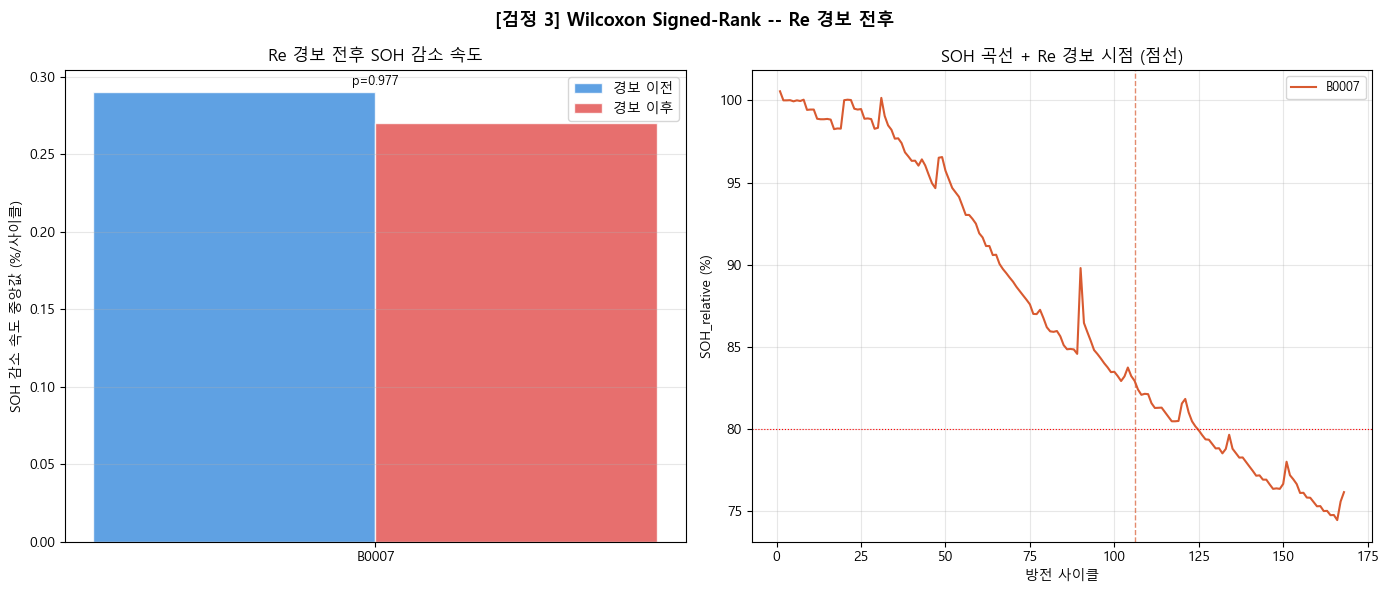

[저장] stat_wilcoxon_alert.png


In [8]:
print("\n" + "=" * 60)
print("검정 3. Wilcoxon Signed-Rank")
print("Re 경보 전후 SOH 감소 속도 비교")
print("=" * 60)
 
re_alert_results = []
for bid in batteries:
    b = df_A_valid[df_A_valid['battery_id']==bid].dropna(subset=['Re_mean','SOH_diff']).copy()
    re_init = b['Re_mean'].head(10).mean()
    alert_threshold = re_init * 1.2
    alert_rows = b[b['Re_mean'] > alert_threshold]
    if len(alert_rows) == 0:
        print(f"{bid}: Re 경보 없음 -> 제외")
        continue
    alert_cycle = alert_rows['discharge_cycle_raw'].min()
    before = b[b['discharge_cycle_raw'] < alert_cycle]['SOH_diff'].abs().values
    after  = b[b['discharge_cycle_raw'] >= alert_cycle]['SOH_diff'].abs().values
    if len(before) < 5 or len(after) < 5:
        print(f"{bid}: 샘플 부족 -> 제외")
        continue
    n = min(len(before), len(after))
    stat_w, p_w = wilcoxon(before[:n], after[:n], alternative='less')
    diff_med = np.median(after[:n]) - np.median(before[:n])
    print(f"\n{bid}:")
    print(f"  경보 시점: {int(alert_cycle)}사이클 (Re 초기 {re_init:.4f}Ohm의 120%)")
    print(f"  경보 전 중앙값: {np.median(before[:n]):.4f}%/사이클")
    print(f"  경보 후 중앙값: {np.median(after[:n]):.4f}%/사이클")
    print(f"  차이: {diff_med:+.4f}")
    print(f"  Wilcoxon p={p_w:.4f} [{'경보 후 유의미하게 빨라짐' if p_w < 0.05 else '유의미하지 않음'}]")
    re_alert_results.append({
        'battery_id': bid, 'alert_cycle': alert_cycle,
        'before': np.median(before[:n]), 'after': np.median(after[:n]), 'p': p_w
    })
 
if re_alert_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    res_df = pd.DataFrame(re_alert_results)
    x = range(len(res_df))
    w = 0.35
    axes[0].bar([i-w/2 for i in x], res_df['before'], width=w,
                label='경보 이전', color='#378ADD', alpha=0.8, edgecolor='white')
    axes[0].bar([i+w/2 for i in x], res_df['after'], width=w,
                label='경보 이후', color='#E24B4A', alpha=0.8, edgecolor='white')
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(res_df['battery_id'])
    axes[0].set_ylabel('SOH 감소 속도 중앙값 (%/사이클)')
    axes[0].set_title('Re 경보 전후 SOH 감소 속도')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    for idx, (_, row) in enumerate(res_df.iterrows()):
        axes[0].text(idx, max(row['before'], row['after']) + 0.005,
                     f'p={row["p"]:.3f}', ha='center', fontsize=9)
 
    for bid in res_df['battery_id']:
        b = df_A_valid[df_A_valid['battery_id']==bid]
        alert_c = res_df[res_df['battery_id']==bid]['alert_cycle'].values[0]
        axes[1].plot(b['discharge_cycle_raw'], b['SOH_relative'],
                     color=BATTERY_COLORS.get(bid,'gray'), linewidth=1.5, label=bid)
        axes[1].axvline(x=alert_c, color=BATTERY_COLORS.get(bid,'gray'),
                        linestyle='--', linewidth=1, alpha=0.7)
    axes[1].axhline(y=80, color='red', linestyle=':', linewidth=0.8)
    axes[1].set_xlabel('방전 사이클')
    axes[1].set_ylabel('SOH_relative (%)')
    axes[1].set_title('SOH 곡선 + Re 경보 시점 (점선)')
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)
    plt.suptitle('[검정 3] Wilcoxon Signed-Rank -- Re 경보 전후', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('stat_wilcoxon_alert.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[저장] stat_wilcoxon_alert.png')


검정 4. Point-Biserial 상관
초기 Re vs B0006 여부 (이진변수)

[사이클별 Re 기준]
Point-Biserial r=0.6674, p=0.0000
해석: B0006이 Re 유의미하게 높음

[배터리별 초기 Re]
  B0005: 0.0452 Ohm 
  B0006: 0.0617 Ohm <-- B0006
  B0007: 0.0395 Ohm 
  B0018: 0.0629 Ohm 


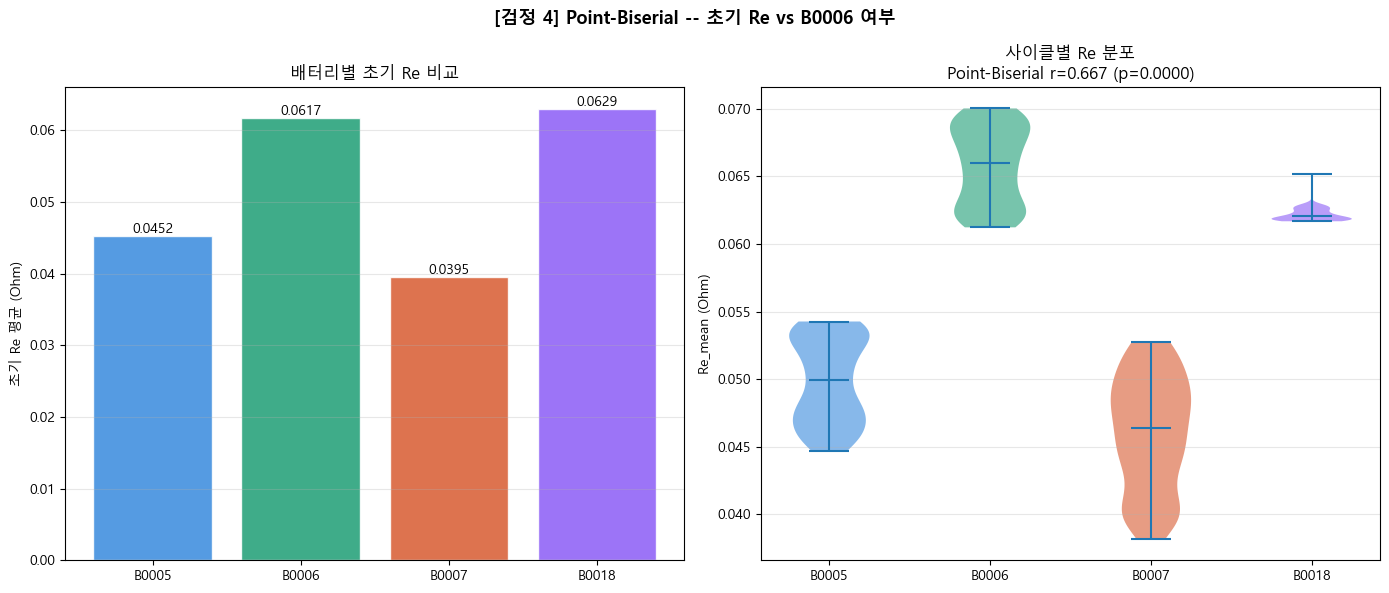

[저장] stat_pointbiserial_re.png


In [9]:
print("\n" + "=" * 60)
print("검정 4. Point-Biserial 상관")
print("초기 Re vs B0006 여부 (이진변수)")
print("=" * 60)
 
init_re = {}
for bid in batteries:
    b = df_A_valid[df_A_valid['battery_id']==bid]['Re_mean'].dropna().head(10)
    init_re[bid] = b.mean()
 
rows = []
for bid in batteries:
    b = df_A_valid[df_A_valid['battery_id']==bid].dropna(subset=['Re_mean'])
    for _, row in b.iterrows():
        rows.append({'battery_id': bid,
                     'is_b0006': 1 if bid=='B0006' else 0,
                     're_mean': row['Re_mean']})
pb_df = pd.DataFrame(rows)
 
r_cycle, p_cycle = pointbiserialr(pb_df['is_b0006'], pb_df['re_mean'])
print(f"\n[사이클별 Re 기준]")
print(f"Point-Biserial r={r_cycle:.4f}, p={p_cycle:.4f}")
print(f"해석: {'B0006이 Re 유의미하게 높음' if p_cycle < 0.05 else '유의미하지 않음'}")
 
print(f"\n[배터리별 초기 Re]")
for bid in batteries:
    marker = '<-- B0006' if bid=='B0006' else ''
    print(f"  {bid}: {init_re[bid]:.4f} Ohm {marker}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bar_colors = [BATTERY_COLORS.get(b,'gray') for b in batteries]
bars = axes[0].bar(batteries, [init_re[b] for b in batteries],
                   color=bar_colors, alpha=0.85, edgecolor='white')
for bar, bid in zip(bars, batteries):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f'{init_re[bid]:.4f}', ha='center', fontsize=10)
axes[0].set_ylabel('초기 Re 평균 (Ohm)')
axes[0].set_title('배터리별 초기 Re 비교')
axes[0].grid(axis='y', alpha=0.3)
 
parts = axes[1].violinplot(
    [pb_df[pb_df['battery_id']==bid]['re_mean'].values for bid in batteries],
    positions=range(len(batteries)), showmedians=True
)
for pc, bid in zip(parts['bodies'], batteries):
    pc.set_facecolor(BATTERY_COLORS.get(bid,'gray'))
    pc.set_alpha(0.6)
axes[1].set_xticks(range(len(batteries)))
axes[1].set_xticklabels(batteries)
axes[1].set_ylabel('Re_mean (Ohm)')
axes[1].set_title(f'사이클별 Re 분포\nPoint-Biserial r={r_cycle:.3f} (p={p_cycle:.4f})')
axes[1].grid(axis='y', alpha=0.3)
plt.suptitle('[검정 4] Point-Biserial -- 초기 Re vs B0006 여부', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_pointbiserial_re.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_pointbiserial_re.png')
 


검정 5. KS 검정
정상 vs 극한 조건 배터리 Capacity 분포 비교

정상(그룹A) n=636, 극한(F/G/I) n=858
정상 평균=1.5817, 극한 평균=1.1871
KS 통계량=0.6447, p=0.0000
해석: 두 분포 유의미하게 다름

[그룹A 내] B0006 vs 나머지: KS=0.2115, p=0.0000
해석: B0006 분포 유의미하게 다름


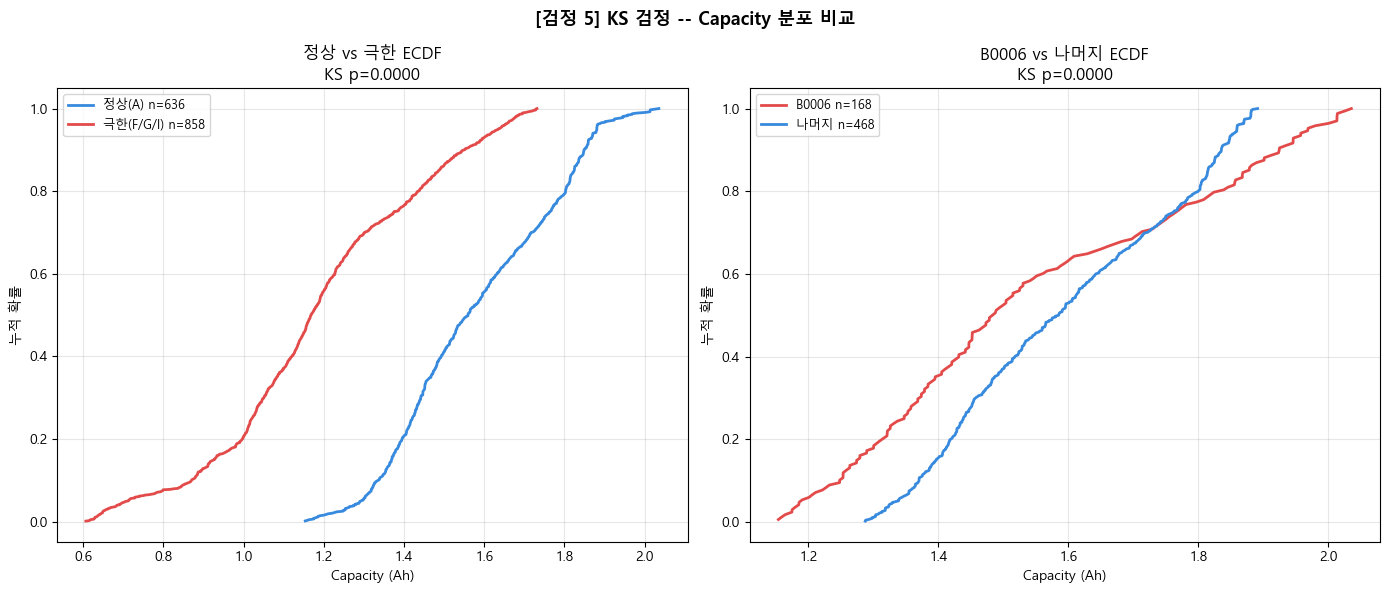

[저장] stat_ks_capacity.png


In [10]:
print("\n" + "=" * 60)
print("검정 5. KS 검정")
print("정상 vs 극한 조건 배터리 Capacity 분포 비교")
print("=" * 60)
 
normal_cap = df_A_valid['Capacity'].dropna().values
df_all     = pd.read_csv(os.path.join(base_path, 'df_discharge_processed.csv'))
df_extreme = df_all[
    (df_all['analysis_role'] == 'anomaly') &
    (df_all['cap_flag'] == 'valid') &
    (df_all['group'].isin(['F','G','I']))
]['Capacity'].dropna().values
 
print(f"\n정상(그룹A) n={len(normal_cap)}, 극한(F/G/I) n={len(df_extreme)}")
print(f"정상 평균={normal_cap.mean():.4f}, 극한 평균={df_extreme.mean():.4f}")
 
stat_ks, p_ks = ks_2samp(normal_cap, df_extreme)
print(f"KS 통계량={stat_ks:.4f}, p={p_ks:.4f}")
print(f"해석: {'두 분포 유의미하게 다름' if p_ks < 0.05 else '차이 없음'}")
 
b0006_cap  = df_A_valid[df_A_valid['battery_id']=='B0006']['Capacity'].dropna().values
others_cap = df_A_valid[df_A_valid['battery_id']!='B0006']['Capacity'].dropna().values
stat_ks2, p_ks2 = ks_2samp(b0006_cap, others_cap)
print(f"\n[그룹A 내] B0006 vs 나머지: KS={stat_ks2:.4f}, p={p_ks2:.4f}")
print(f"해석: {'B0006 분포 유의미하게 다름' if p_ks2 < 0.05 else '차이 없음'}")
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x1, y1 = ecdf(normal_cap)
x2, y2 = ecdf(df_extreme)
axes[0].plot(x1, y1, color='#378ADD', linewidth=2, label=f'정상(A) n={len(normal_cap)}')
axes[0].plot(x2, y2, color='#E24B4A', linewidth=2, label=f'극한(F/G/I) n={len(df_extreme)}')
axes[0].set_xlabel('Capacity (Ah)')
axes[0].set_ylabel('누적 확률')
axes[0].set_title(f'정상 vs 극한 ECDF\nKS p={p_ks:.4f}')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
 
x3, y3 = ecdf(b0006_cap)
x4, y4 = ecdf(others_cap)
axes[1].plot(x3, y3, color='#E24B4A', linewidth=2, label=f'B0006 n={len(b0006_cap)}')
axes[1].plot(x4, y4, color='#378ADD', linewidth=2, label=f'나머지 n={len(others_cap)}')
axes[1].set_xlabel('Capacity (Ah)')
axes[1].set_ylabel('누적 확률')
axes[1].set_title(f'B0006 vs 나머지 ECDF\nKS p={p_ks2:.4f}')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.suptitle('[검정 5] KS 검정 -- Capacity 분포 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_ks_capacity.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_ks_capacity.png')
 


검정 6. QQ Plot + Shapiro-Wilk


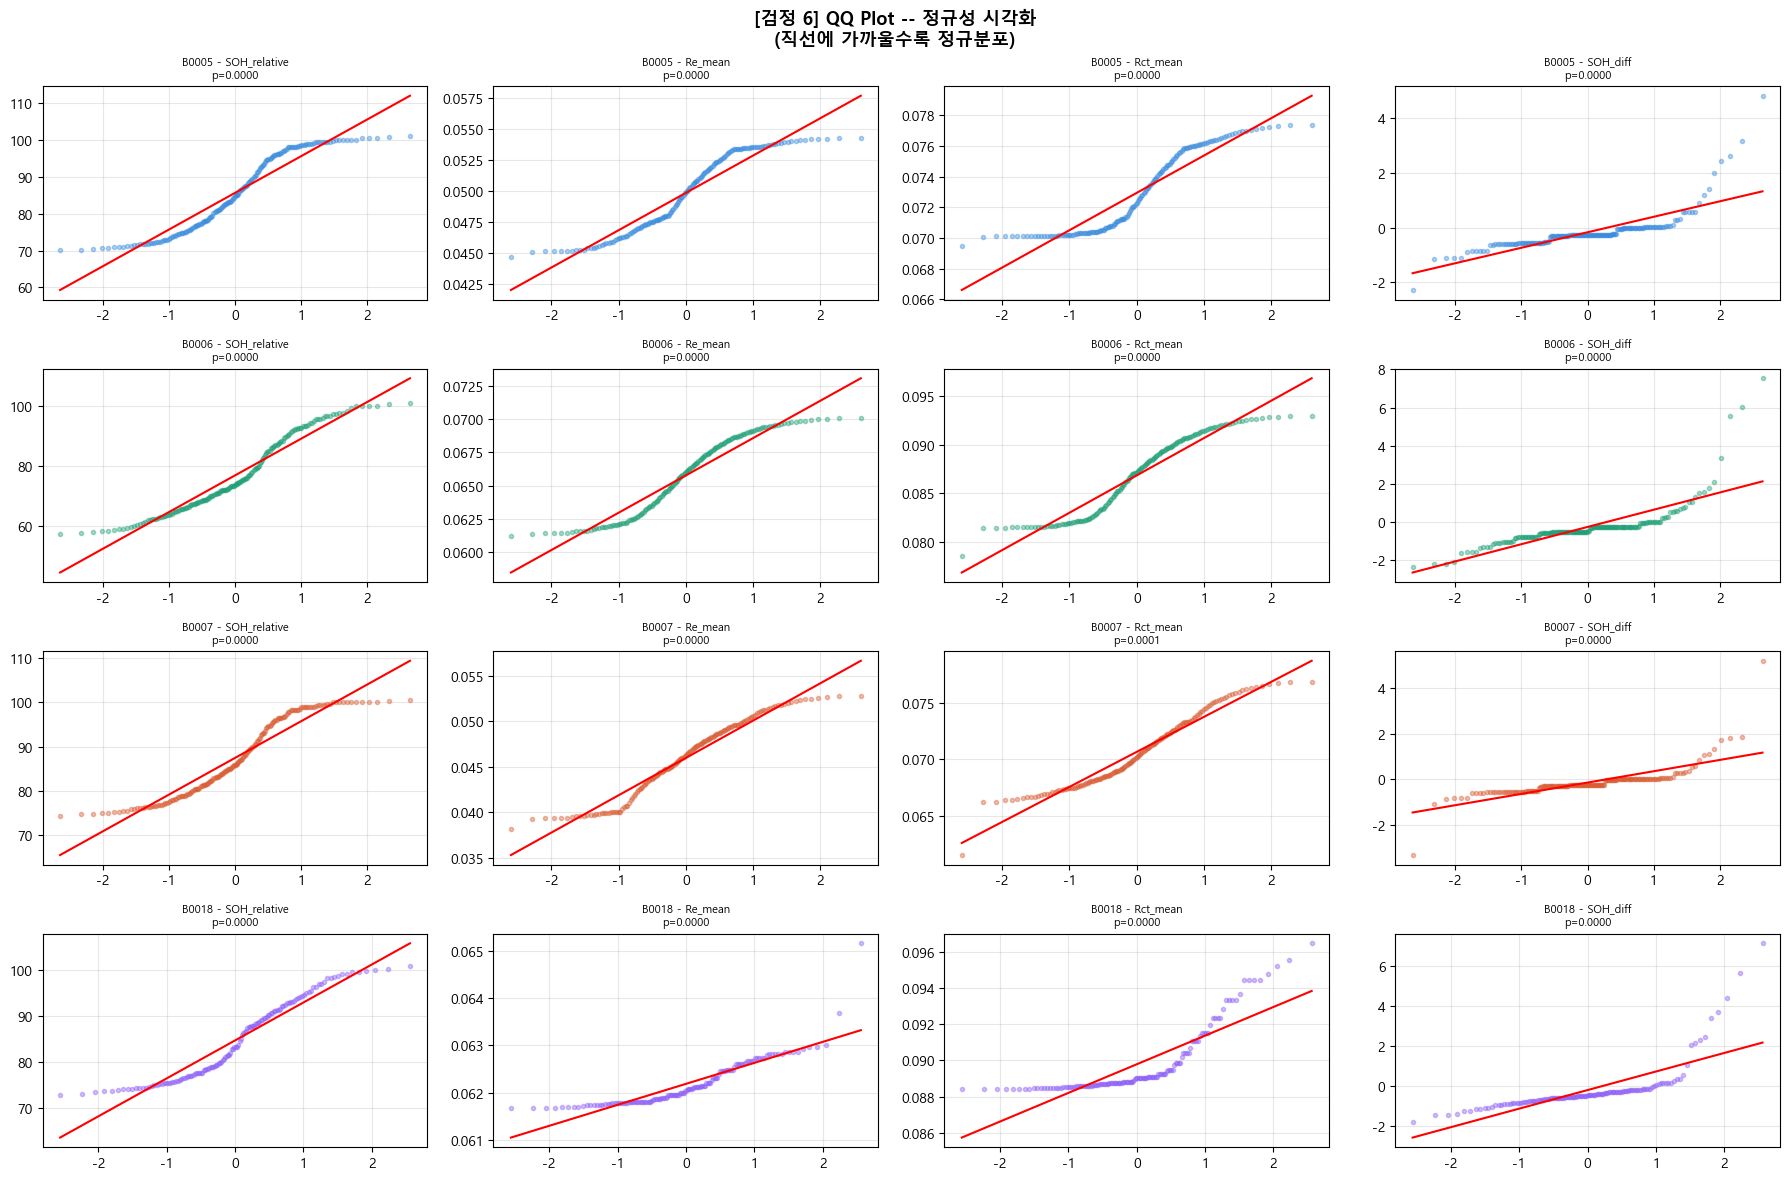

[저장] stat_qq_plot.png


In [11]:
print("\n" + "=" * 60)
print("검정 6. QQ Plot + Shapiro-Wilk")
print("=" * 60)
 
variables   = ['SOH_relative', 'Re_mean', 'Rct_mean', 'SOH_diff']
test_bids   = ['B0005','B0006','B0007','B0018']
 
fig, axes = plt.subplots(len(test_bids), len(variables), figsize=(18, 12))
 
for row_i, bid in enumerate(test_bids):
    for col_i, col_name in enumerate(variables):
        ax = axes[row_i][col_i]
        data = df_A_valid[df_A_valid['battery_id']==bid][col_name].dropna().values
        if len(data) < 3:
            ax.set_visible(False)
            continue
        stat_sw, p_sw = shapiro(data[:min(len(data), 5000)])
        (osm, osr), (slope, intercept, r) = probplot(data, dist='norm')
        ax.plot(osm, osr, 'o', color=BATTERY_COLORS.get(bid,'gray'), alpha=0.4, markersize=3)
        ax.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.5)
        ax.set_title(f'{bid} - {col_name}\np={p_sw:.4f}', fontsize=8)
        ax.grid(alpha=0.3)
 
plt.suptitle('[검정 6] QQ Plot -- 정규성 시각화\n(직선에 가까울수록 정규분포)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_qq_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] stat_qq_plot.png')

In [ ]:
base_path = 'data/new_data'


df_A = pd.read_csv(os.path.join(base_path, 'df_A_main.csv'))
df_imp_A = pd.read_csv(os.path.join(base_path, 'df_imp_A_main.csv'))
 
df_A_valid = df_A[df_A['cap_flag'] == 'valid'].copy()
df_A_valid = df_A_valid.sort_values(['battery_id', 'discharge_cycle_raw'])
 
# start_time datetime 변환
df_A_valid['start_time'] = pd.to_datetime(df_A_valid['start_time'])
df_imp_A['start_time']   = pd.to_datetime(df_imp_A['start_time'])
 
# impedance merge_asof
df_imp_A['Re']  = pd.to_numeric(df_imp_A['Re'],  errors='coerce')
df_imp_A['Rct'] = pd.to_numeric(df_imp_A['Rct'], errors='coerce')
df_imp_A = df_imp_A.sort_values(['battery_id', 'start_time']).reset_index(drop=True)
df_imp_A['Re_cumean']  = (df_imp_A.groupby('battery_id')['Re']
                          .expanding().mean().reset_index(level=0, drop=True))
df_imp_A['Rct_cumean'] = (df_imp_A.groupby('battery_id')['Rct']
                          .expanding().mean().reset_index(level=0, drop=True))
 
results = []
for bid in df_A_valid['battery_id'].unique():
    d = df_A_valid[df_A_valid['battery_id']==bid].sort_values('start_time').reset_index(drop=True)
    i = df_imp_A[df_imp_A['battery_id']==bid][['start_time','Re_cumean','Rct_cumean']].sort_values('start_time').reset_index(drop=True)
    merged = pd.merge_asof(d, i, on='start_time', direction='backward')
    results.append(merged)
 
df_A_valid = pd.concat(results, ignore_index=True)
df_A_valid = df_A_valid.rename(columns={'Re_cumean':'Re_mean','Rct_cumean':'Rct_mean'})
df_A_valid = df_A_valid.sort_values(['battery_id', 'discharge_cycle_raw'])
df_A_valid['Re_mean']  = df_A_valid.groupby('battery_id')['Re_mean'].ffill()
df_A_valid['Rct_mean'] = df_A_valid.groupby('battery_id')['Rct_mean'].ffill()
 
# EOL & RUL
eol_A = (df_A_valid[df_A_valid['SOH_nominal'] < 70]
         .groupby('battery_id')['discharge_cycle_raw']
         .min().rename('eol'))
df_A_valid = df_A_valid.merge(eol_A, on='battery_id', how='left')
df_A_valid['RUL'] = (df_A_valid['eol'] - df_A_valid['discharge_cycle_raw']).clip(lower=0)
 
df_rul = df_A_valid.dropna(subset=['Re_mean', 'Rct_mean', 'RUL', 'SOH_relative']).copy()
 
BATTERY_COLORS = {
    'B0005': '#378ADD',
    'B0006': '#E24B4A',
    'B0007': '#D85A30',
    'B0018': '#8B5CF6',
}

Re·Rct·SOH vs RUL 상관계수
Re-RUL:  r=-0.4828,  p=0.0000
Rct-RUL: r=-0.2913, p=0.0000
SOH-RUL: r=0.9232, p=0.0000

해석:
  Re-RUL r=-0.483: 중간 강도 음의 상관
  SOH-RUL r=0.923: 매우 강한 양의 상관 (자명한 결과)
  → Re가 SOH와 독립적으로 RUL에 추가 정보를 줄 가능성


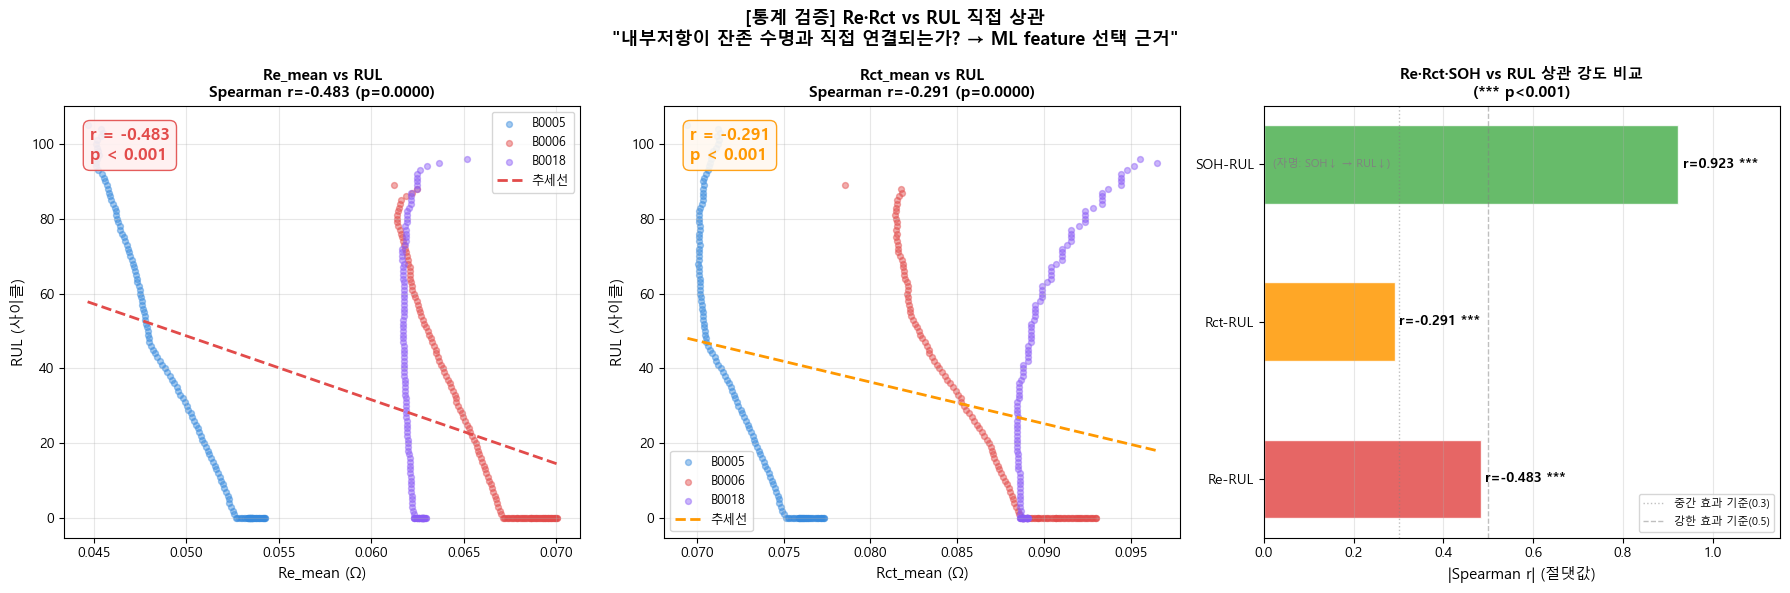


[저장] stat_re_rul_correlation.png

[발표 핵심 수치]
  Re-RUL:  r=-0.483 (p<0.001) — 중간 강도
  Rct-RUL: r=-0.291 (p<0.001)
  SOH-RUL: r=0.923 (p<0.001) — 매우 강함 (자명한 결과)

[ML 연결 포인트]
  Re가 RUL과 직접 음의 상관 (r=-0.483)
  → Re를 ML feature로 선택하는 가장 직접적인 통계 근거
  → SOH와 독립적으로 추가 정보를 줄 가능성


In [7]:
from scipy.stats import spearmanr

r_re,  p_re  = spearmanr(df_rul['Re_mean'],  df_rul['RUL'])
r_rct, p_rct = spearmanr(df_rul['Rct_mean'], df_rul['RUL'])
r_soh, p_soh = spearmanr(df_rul['SOH_relative'], df_rul['RUL'])
 
print("=" * 55)
print("Re·Rct·SOH vs RUL 상관계수")
print("=" * 55)
print(f"Re-RUL:  r={r_re:.4f},  p={p_re:.4f}")
print(f"Rct-RUL: r={r_rct:.4f}, p={p_rct:.4f}")
print(f"SOH-RUL: r={r_soh:.4f}, p={p_soh:.4f}")
print(f"\n해석:")
print(f"  Re-RUL r={r_re:.3f}: 중간 강도 음의 상관")
print(f"  SOH-RUL r={r_soh:.3f}: 매우 강한 양의 상관 (자명한 결과)")
print(f"  → Re가 SOH와 독립적으로 RUL에 추가 정보를 줄 가능성")
 
# ============================================================
# 시각화
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
 
# ---- 왼쪽: Re vs RUL 산점도 ----
for bid in df_rul['battery_id'].unique():
    b = df_rul[df_rul['battery_id'] == bid]
    color = BATTERY_COLORS.get(bid, 'gray')
    axes[0].scatter(b['Re_mean'], b['RUL'],
                    color=color, alpha=0.45, s=18, label=bid)
 
# OLS 추세선
m, b_coef = np.polyfit(df_rul['Re_mean'], df_rul['RUL'], 1)
x_line = np.linspace(df_rul['Re_mean'].min(), df_rul['Re_mean'].max(), 100)
axes[0].plot(x_line, m*x_line + b_coef,
             color='#E24B4A', linewidth=2, linestyle='--', label='추세선')
 
axes[0].set_xlabel('Re_mean (Ω)', fontsize=11)
axes[0].set_ylabel('RUL (사이클)', fontsize=11)
axes[0].set_title(f'Re_mean vs RUL\nSpearman r={r_re:.3f} (p={p_re:.4f})',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
 
# r값 강조 박스
axes[0].text(0.05, 0.95,
             f'r = {r_re:.3f}\np < 0.001',
             transform=axes[0].transAxes,
             fontsize=12, fontweight='bold',
             va='top', color='#E24B4A',
             bbox=dict(boxstyle='round,pad=0.4',
                       facecolor='#fff0f0', edgecolor='#E24B4A', alpha=0.9))
 
# ---- 가운데: Rct vs RUL 산점도 ----
for bid in df_rul['battery_id'].unique():
    b = df_rul[df_rul['battery_id'] == bid]
    color = BATTERY_COLORS.get(bid, 'gray')
    axes[1].scatter(b['Rct_mean'], b['RUL'],
                    color=color, alpha=0.45, s=18, label=bid)
 
m2, b2 = np.polyfit(df_rul['Rct_mean'], df_rul['RUL'], 1)
x_line2 = np.linspace(df_rul['Rct_mean'].min(), df_rul['Rct_mean'].max(), 100)
axes[1].plot(x_line2, m2*x_line2 + b2,
             color='#FF9800', linewidth=2, linestyle='--', label='추세선')
 
axes[1].set_xlabel('Rct_mean (Ω)', fontsize=11)
axes[1].set_ylabel('RUL (사이클)', fontsize=11)
axes[1].set_title(f'Rct_mean vs RUL\nSpearman r={r_rct:.3f} (p={p_rct:.4f})',
                  fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
 
axes[1].text(0.05, 0.95,
             f'r = {r_rct:.3f}\np < 0.001',
             transform=axes[1].transAxes,
             fontsize=12, fontweight='bold',
             va='top', color='#FF9800',
             bbox=dict(boxstyle='round,pad=0.4',
                       facecolor='#fff8f0', edgecolor='#FF9800', alpha=0.9))
 
# ---- 오른쪽: 상관계수 비교 바차트 ----
variables  = ['Re-RUL', 'Rct-RUL', 'SOH-RUL']
r_values   = [r_re, r_rct, r_soh]
bar_colors = ['#E24B4A', '#FF9800', '#4CAF50']
 
bars = axes[2].barh(variables, [abs(r) for r in r_values],
                    color=bar_colors, alpha=0.85, edgecolor='white', height=0.5)
 
for bar, r_val, p_val in zip(bars, r_values, [p_re, p_rct, p_soh]):
    w = bar.get_width()
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else '*')
    axes[2].text(w + 0.01, bar.get_y() + bar.get_height()/2,
                 f'r={r_val:.3f} {sig}',
                 va='center', fontsize=10, fontweight='bold')
 
# SOH-RUL에 "자명한 결과" 주석
axes[2].text(0.02, 2,
             '(자명: SOH↓ → RUL↓)',
             va='center', fontsize=8, color='gray', style='italic')
 
axes[2].set_xlabel('|Spearman r| (절댓값)', fontsize=11)
axes[2].set_title('Re·Rct·SOH vs RUL 상관 강도 비교\n(*** p<0.001)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlim(0, 1.15)
axes[2].axvline(x=0.3, color='gray', linestyle=':', linewidth=1, alpha=0.5,
                label='중간 효과 기준(0.3)')
axes[2].axvline(x=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5,
                label='강한 효과 기준(0.5)')
axes[2].legend(fontsize=8, loc='lower right')
axes[2].grid(axis='x', alpha=0.3)
 
plt.suptitle('[통계 검증] Re·Rct vs RUL 직접 상관\n'
             '"내부저항이 잔존 수명과 직접 연결되는가? → ML feature 선택 근거"',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('stat_re_rul_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
 
print('\n[저장] stat_re_rul_correlation.png')
print('\n[발표 핵심 수치]')
print(f'  Re-RUL:  r={r_re:.3f} (p<0.001) — 중간 강도')
print(f'  Rct-RUL: r={r_rct:.3f} (p<0.001)')
print(f'  SOH-RUL: r={r_soh:.3f} (p<0.001) — 매우 강함 (자명한 결과)')
print(f'\n[ML 연결 포인트]')
print(f'  Re가 RUL과 직접 음의 상관 (r={r_re:.3f})')
print(f'  → Re를 ML feature로 선택하는 가장 직접적인 통계 근거')
print(f'  → SOH와 독립적으로 추가 정보를 줄 가능성')
 